# Part 2 of the video, implementing through pytorch

### Rather than fully relying on Torch, use pygrad for neuron/layer/mlp functions

#### Python torch is an open-source machine learning and deep learning AI module, very useful for neural networks (what we are doing here woah)

#### P.S. -> ~/git-repos/Machine-Learning-for-Simulation$ source .venv/bin/activate run this to activate virtual enviroment

#### to cd quickly: cd Machine-Learning-for-Simulation/nnz2h/nnz2h/01-lessons

#### implement same dependencies as before just incase

In [17]:
import sys
from pathlib import Path

# Add the parent directory (nnz2h) to sys.path
parent_dir = Path.cwd().parent
if str(parent_dir) not in sys.path:
    sys.path.append(str(parent_dir))

import pygrad

import math
import numpy as np
import matplotlib.pyplot as plt
import random

# jupyter magic:
%matplotlib inline

Implement torch

In [18]:
import torch

In [ ]:
# Define objects like before, tensors are singular here

# Need to explicity state a gradient is required

# creates scalar valued one element tensors (leaf nodes)
x1 = torch.Tensor([2.0]).double() ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double() ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double() ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double() ; w2.requires_grad = True

b = torch.Tensor([6.88137]).double() ; b.requires_grad = True

n = x1 * w1 + x2 * w2 + b

o = torch.tanh(n)

print(o.data.item())
o.backward()

print('-----')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071050214706146
-----
x2 0.5000024886110417
w2 0.0
x1 -1.500007465833125
w1 1.0000049772220834


In [20]:
# How to track shape of the tensor

torch.Tensor(([1,2,3],[4,5,6])).shape

# How to track the data type of the tensor

torch.Tensor([2.0]).double().dtype

torch.float64

In [21]:
# o.item() and o.data.item() will produce the same result with PyTorch

o.item()
o.data.item()

0.7071050214706146

<img src="./img/02-Neural-Net.png" width="500">


Neural Net plot example, input and output are easily tracked while inside is what is trained

Video creates these as classes, however pygrad has both Neuron and Layer already set up

In [ ]:
from pygrad import Neuron # one instance of a single neuron which has weights and bias to calculated based on inputs
from pygrad import Layer # one instance of a layer which contains multiple neurons
from pygrad import MLP # one instance of a multi-layer perceptron which contains multiple layers of neurons

# num_i is incoming input amount (size of x)
# num_o is number of neurons in the layer
# num_os is total output size

x = [2.0, 3.0]
n = Neuron(num_i=2, activation="tanh") # 2 dimensional neuron which automatically uses tanh
n(x)

x = [2.0,3.0, -1.0]
n = Layer(num_i = 3, num_o = 4, activation="tanh")
n(x)


x = [2.0, 3.0, -1.0]

# Layer 1 is size 3 (num_i, layer 2 is 4 then 3 is 4 then the output is 1)
m = MLP(num_i = 3, num_os = [4,4,1], activation="tanh")
m(x)

Scalar(value=0.399022,grad=0.000000)

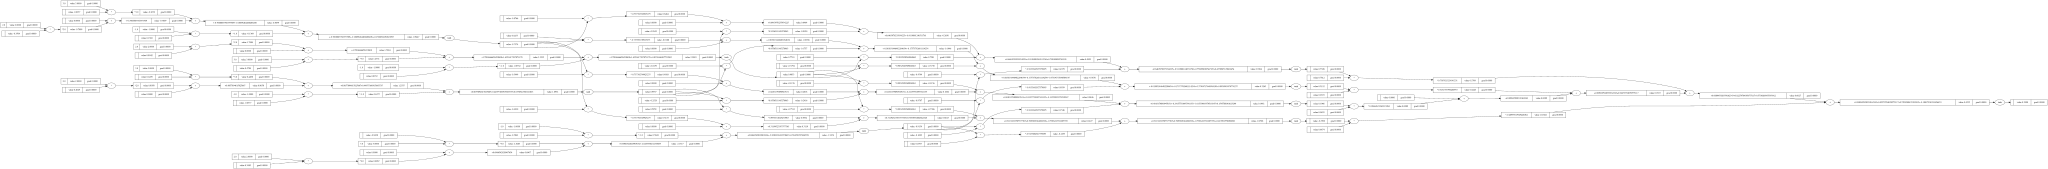

In [23]:
import pygrad.viz as pgv

pgv.draw_graph(m(x))


In [24]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0,1.0,-1.0],
]

ys = [1.0, -1.0, -1.0, 1.0] # desired output for each input in xs



Calculate the loss from the desired output and the computed output
ygt -> ground truth (ys)
yout -> output (ypred)

In [25]:
# pair up ground truths with predictions and the zip iteratres over tuples of the
ypred = [m(x) for x in xs]
loss = sum([(yout-ygt)**2 for ygt, yout in zip(ys,ypred)])
loss # total summation of error, does not show each node error but rather overall

Scalar(value=4.411435,grad=0.000000)

In [26]:
# Accumulate gradients for the loss
for p in m.parameters():
    p.grad = 0.0 # make sure to reset so backward pass accumulates into the grads properly
loss.acc_grads()
m.layers[0].neurons[0].w[0] # since grad is negative and loss is negative, increasing the neuron would make loss go down

# gradients for inputs are useless as inputs are likely not able to be changed

Scalar(value=-0.350443,grad=-1.342565)

We want to be able to gather all parameters so we can nudge the weights a little bit

In [27]:
# use m.parameters() to get the parameters of each part

h = 0.01 # step size

for p in m.parameters(): # iterate over all parameters of the model
    p.value += h * -p.grad # tiny update for gradient descent scheme, negative to minimize the loss

This process now repeats where you calculate the prediction values, then forward pass, backward pass, update

recalculate m.parameters() to see the model that is trained to reach our predicted values

Lets develop a loop that will do the process automatically

In [28]:
# most simple neural network training loop

xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0,1.0,-1.0],
]

ys = [1.0, -1.0, -1.0, 1.0] # desired output for each input in xs

h = 0.01 

for k in range(20):

    # forward pass

    ypred = [m(x) for x in xs]
    loss = sum([(yout-ygt)**2 for ygt, yout in zip(ys,ypred)])
    # backward pass
    for p in m.parameters():
        p.grad = 0.0
    loss.acc_grads()

    #update

    for p in m.parameters():
        p.value += h * -p.grad # simple stochastic update

    print(k,loss.value)    



0 4.071538467203606
1 3.7226817607199143
2 3.366260190775451
3 3.015674084842537
4 2.692502605431556
5 2.4117999263568874
6 2.17330178442821
7 1.9693272354327092
8 1.792765805308292
9 1.6384409302161551
10 1.5025018655425628
11 1.3819670684709031
12 1.2744887337691146
13 1.1782029534192864
14 1.0916148124212894
15 1.0135077084616828
16 0.9428741449192088
17 0.8788649001591177
18 0.8207526946599273
19 0.7679065474001283


For larger networks and future things to implement,
- batching used to only work on parts not fitting
- more complex loss algorithms needed
- Regulaization: Generalization of the neural net and controlling the overfit
- lower the learning rate as learning goes

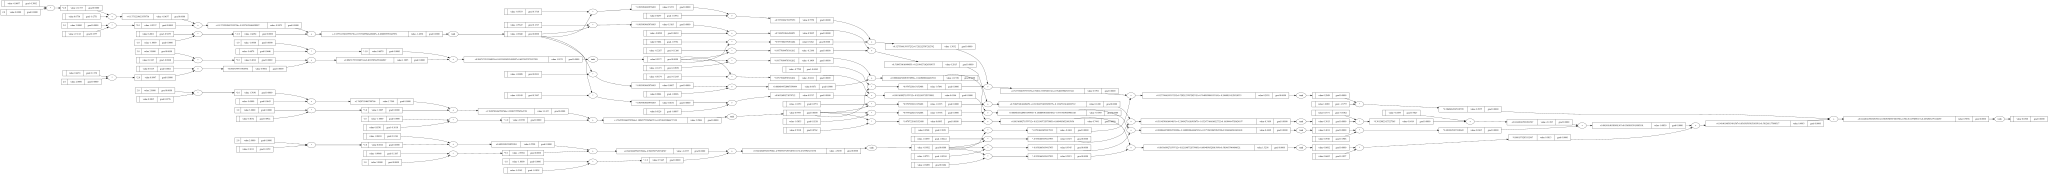

In [29]:
# For fun lets make a graph of the neural network now

pgv.draw_graph(m(x))